# **IMPORT LIBRARY**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualisasi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Library berhasil di-import!")

✅ Library berhasil di-import!


# **DATA COLLECTING**

In [ ]:
print("\n" + "="*60)
print("📊 DATA COLLECTING")
print("="*60)

# Upload file CSV
from google.colab import files
print("\n📤 Upload file CSV dataset Anda:")
print("(Pilih 'Students_Grading_Dataset_Biased.csv' atau 'Students_Performance_Dataset.csv')")
uploaded = files.upload()

# Load CSV file
filename = list(uploaded.keys())[0]
print(f"\n📂 Loading file: {filename}")

# Read CSV
df = pd.read_csv(filename)

print("\n" + "="*60)
print("📊 INFORMASI DATASET")
print("="*60)
print(f"✅ Jumlah Data: {df.shape[0]} baris")
print(f"✅ Jumlah Fitur: {df.shape[1]} kolom")
print(f"✅ Bentuk Data: Tabular (CSV)")
print(f"✅ Jenis Data: Tabular")
print(f"✅ Metode: Supervised Learning")
print(f"✅ Tipe Prediksi: Classification (Grade: A, B, C, D, F)")

# Tampilkan preview data
print("\n📋 Preview 5 Data Pertama:")
print(df.head())

print("\n📊 Informasi Tipe Data:")
print(df.info())

print("\n📈 Statistik Deskriptif:")
print(df.describe())

print("\n📋 Kolom-kolom dalam dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")


📊 DATA COLLECTING

📤 Upload file CSV dataset Anda:
(Pilih 'Students_Grading_Dataset_Biased.csv' atau 'Students_Performance_Dataset.csv')


Saving Students_Performance_Dataset.csv to Students_Performance_Dataset.csv

📂 Loading file: Students_Performance_Dataset.csv

📊 INFORMASI DATASET
✅ Jumlah Data: 5000 baris
✅ Jumlah Fitur: 23 kolom
✅ Bentuk Data: Tabular (CSV)
✅ Jenis Data: Tabular
✅ Metode: Supervised Learning
✅ Tipe Prediksi: Classification (Grade: A, B, C, D, F)

📋 Preview 5 Data Pertama:
  Student_ID First_Name Last_Name                    Email  Gender  Age  \
0      S1000       Omar  Williams  student0@university.com  Female   22   
1      S1001      Maria     Brown  student1@university.com    Male   18   
2      S1002      Ahmed     Jones  student2@university.com    Male   24   
3      S1003       Omar  Williams  student3@university.com  Female   24   
4      S1004       John     Smith  student4@university.com  Female   23   

    Department  Attendance (%)  Midterm_Score  Final_Score  ...  \
0  Mathematics           97.36          40.61        59.61  ...   
1     Business           97.71          57.27        7

# **DATA PREPROCESSING**

In [ ]:
print("\n" + "="*60)
print("🔧 DATA PREPROCESSING")
print("="*60)

# Step 1: Cek missing values
print("\n1️⃣ Checking Missing Values:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("✅ No missing values!")

# Step 2: Handle missing values
df_clean = df.dropna()
print(f"   Data setelah cleaning: {df_clean.shape[0]} baris")

# Step 3: Cek duplikasi
duplicates = df_clean.duplicated().sum()
print(f"\n2️⃣ Duplicate Records: {duplicates}")
if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"   Data setelah remove duplicates: {df_clean.shape[0]} baris")

# Step 4: Identifikasi kolom
print("\n3️⃣ Feature Selection:")

# Kolom yang tidak digunakan untuk modeling
exclude_cols = ['Student_ID', 'First_Name', 'Last_Name', 'Email', 'Total_Score']

# Identifikasi target column
if 'Grade' in df_clean.columns:
    target_col = 'Grade'
elif 'grade' in df_clean.columns:
    target_col = 'grade'
else:
    target_col = df_clean.columns[-1]

# Pisahkan numeric dan categorical features
all_feature_cols = [col for col in df_clean.columns if col not in exclude_cols and col != target_col]

numeric_features = []
categorical_features = []

for col in all_feature_cols:
    if df_clean[col].dtype in ['int64', 'float64']:
        numeric_features.append(col)
    else:
        categorical_features.append(col)

print(f"   Target: {target_col}")
print(f"   Numeric Features ({len(numeric_features)}): {numeric_features[:5]}...")
print(f"   Categorical Features ({len(categorical_features)}): {categorical_features}")

# Step 5: Prepare features
X_numeric = df_clean[numeric_features].copy()
X_categorical = df_clean[categorical_features].copy() if categorical_features else pd.DataFrame()

# Encode categorical features
print("\n4️⃣ Encoding Categorical Variables:")
le_dict = {}
if len(categorical_features) > 0:
    for col in categorical_features:
        le = LabelEncoder()
        X_categorical[col] = le.fit_transform(X_categorical[col].astype(str))
        le_dict[col] = le
        unique_vals = list(le.classes_[:3]) + (['...'] if len(le.classes_) > 3 else [])
        print(f"   {col}: {unique_vals}")

# Combine features
if len(categorical_features) > 0:
    X = pd.concat([X_numeric, X_categorical], axis=1)
else:
    X = X_numeric

# Encode target
y = df_clean[target_col]
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
print(f"\n   Target Classes: {list(le_target.classes_)}")
print(f"   Encoded as: {list(range(len(le_target.classes_)))}")

# Step 6: Feature Scaling
print("\n5️⃣ Feature Normalization (Standardization):")
print("-" * 60)
print("📐 Menggunakan StandardScaler:")
print("   Formula: X_scaled = (X - mean) / std_deviation")
print("   - Mengubah data ke distribusi dengan mean=0, std=1")
print("   - Semua fitur dalam skala yang sama")
print("   - Penting untuk algoritma berbasis jarak (seperti Random Forest)")
print("-" * 60)

# Tampilkan statistik SEBELUM normalisasi
print("\n📊 SEBELUM Normalisasi (Original Scale):")
print("=" * 90)
print(f"{'No':<4} {'Feature Name':<35} {'Mean':>10} {'Std Dev':>10} {'Min':>10} {'Max':>10}")
print("=" * 90)
for idx, col in enumerate(X.columns, 1):
    mean_val = X[col].mean()
    std_val = X[col].std()
    min_val = X[col].min()
    max_val = X[col].max()
    print(f"{idx:<4} {col:<35} {mean_val:>10.2f} {std_val:>10.2f} {min_val:>10.2f} {max_val:>10.2f}")
print("=" * 90)
print(f"Total Features: {len(X.columns)}")

# Lakukan normalisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Tampilkan statistik SESUDAH normalisasi
print("\n📊 SESUDAH Normalisasi (Standardized Scale):")
print("=" * 90)
print(f"{'No':<4} {'Feature Name':<35} {'Mean':>10} {'Std Dev':>10} {'Min':>10} {'Max':>10}")
print("=" * 90)
for idx, col in enumerate(X_scaled.columns, 1):
    mean_val = X_scaled[col].mean()
    std_val = X_scaled[col].std()
    min_val = X_scaled[col].min()
    max_val = X_scaled[col].max()
    print(f"{idx:<4} {col:<35} {mean_val:>10.2f} {std_val:>10.2f} {min_val:>10.2f} {max_val:>10.2f}")
print("=" * 90)
print(f"Total Features: {len(X_scaled.columns)}")

print("\n✅ Perhatikan: Mean ≈ 0 dan Std Dev ≈ 1 untuk semua features!")

# Step 7: Train-Test Split
print("\n6️⃣ Train-Test Split:")

# Cek distribusi kelas
print("\n   Distribusi Kelas dalam Dataset:")
class_distribution = pd.Series(y_encoded).value_counts().sort_index()
for i, (class_idx, count) in enumerate(class_distribution.items()):
    class_name = le_target.classes_[class_idx]
    percentage = (count / len(y_encoded)) * 100
    print(f"   - Grade {class_name}: {count} samples ({percentage:.1f}%)")

# Gunakan test_size yang lebih besar jika dataset kecil
# Atau test_size lebih kecil jika ada kelas dengan sample sedikit
min_class_count = class_distribution.min()
if min_class_count < 10:
    test_size = 0.15  # 15% untuk test jika ada kelas dengan < 10 samples
    print(f"\n   ⚠️ Warning: Kelas dengan sample sedikit ({min_class_count})")
    print(f"   Menggunakan test_size=0.15 untuk memastikan cukup data di setiap kelas")
else:
    test_size = 0.2   # 20% untuk test

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=test_size, random_state=42, stratify=y_encoded
)

print(f"\n   Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"   Testing set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X_scaled)*100:.1f}%)")

# Tampilkan distribusi di train dan test set
print("\n   Distribusi di Test Set:")
test_distribution = pd.Series(y_test).value_counts().sort_index()
for i, (class_idx, count) in enumerate(test_distribution.items()):
    class_name = le_target.classes_[class_idx]
    print(f"   - Grade {class_name}: {count} samples")

print("\n✅ Preprocessing selesai!")


🔧 DATA PREPROCESSING

1️⃣ Checking Missing Values:
Parent_Education_Level    1025
dtype: int64
   Data setelah cleaning: 3975 baris

2️⃣ Duplicate Records: 0

3️⃣ Feature Selection:
   Target: Grade
   Numeric Features (11): ['Age', 'Attendance (%)', 'Midterm_Score', 'Final_Score', 'Assignments_Avg']...
   Categorical Features (6): ['Gender', 'Department', 'Extracurricular_Activities', 'Internet_Access_at_Home', 'Parent_Education_Level', 'Family_Income_Level']

4️⃣ Encoding Categorical Variables:
   Gender: ['Female', 'Male']
   Department: ['Business', 'CS', 'Engineering', '...']
   Extracurricular_Activities: ['No', 'Yes']
   Internet_Access_at_Home: ['No', 'Yes']
   Parent_Education_Level: ["Bachelor's", 'High School', "Master's", '...']
   Family_Income_Level: ['High', 'Low', 'Medium']

   Target Classes: ['A', 'B', 'C', 'D', 'F']
   Encoded as: [0, 1, 2, 3, 4]

5️⃣ Feature Normalization (Standardization):
------------------------------------------------------------
📐 Menggunakan 

# **DATA ANALYSIS & VISUALIZATION**


📊 DATA ANALYSIS & VISUALIZATION


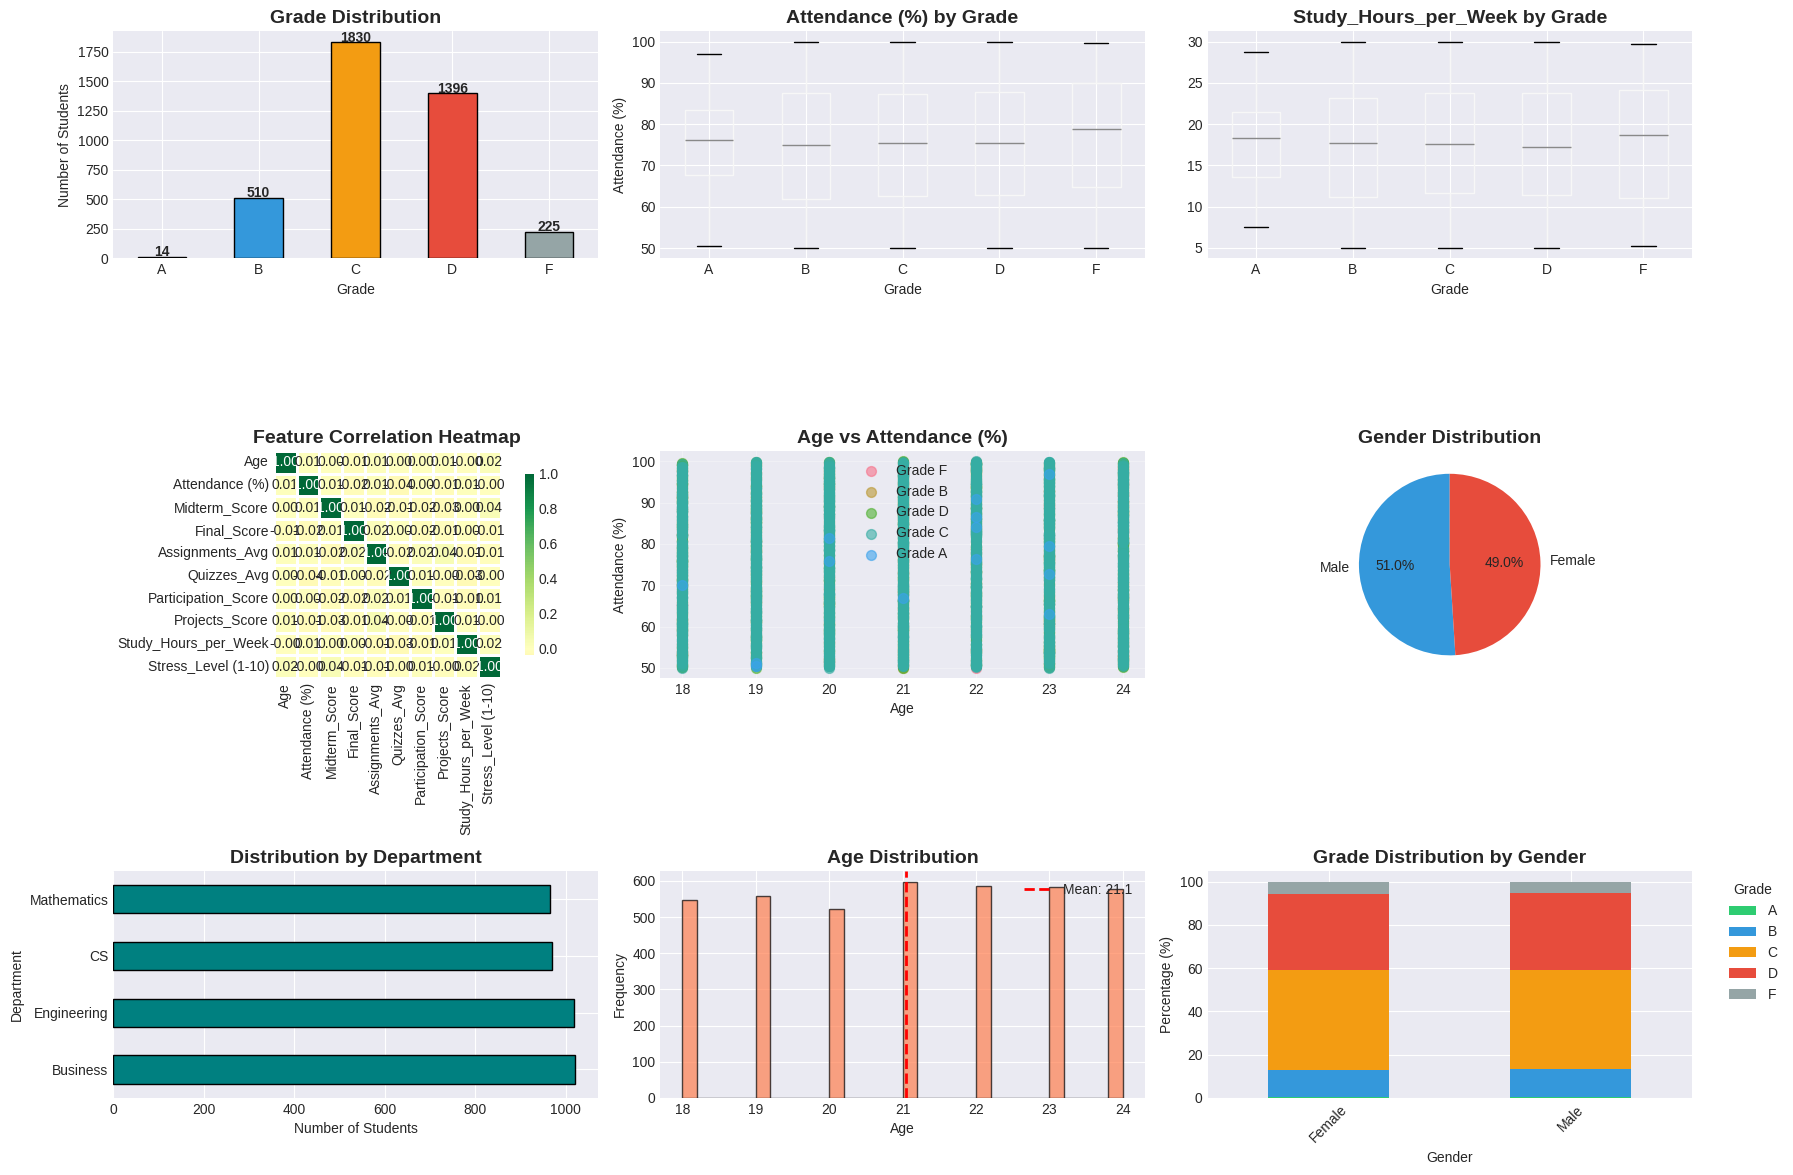


✅ Visualisasi analisis data tersimpan sebagai 'data_analysis_comprehensive.png'

📊 METADATA & STATISTICAL INSIGHTS

1. Grade Distribution:
   Grade A: 14 students (0.4%)
   Grade B: 510 students (12.8%)
   Grade C: 1830 students (46.0%)
   Grade D: 1396 students (35.1%)
   Grade F: 225 students (5.7%)

2. Average Numeric Features by Grade:
         Age  Attendance (%)  Midterm_Score
Grade                                      
A      21.21           74.74          91.21
B      21.22           74.96          79.49
C      21.01           75.16          72.85
D      21.03           75.26          66.72
F      21.14           77.16          56.81

3. Correlation with Target (if numeric):
Attendance (%)           0.022
Study_Hours_per_Week    -0.000
Stress_Level (1-10)     -0.007
Age                     -0.012
Sleep_Hours_per_Night   -0.026
Name: target_numeric, dtype: float64


In [ ]:
print("\n" + "="*60)
print("📊 DATA ANALYSIS & VISUALIZATION")
print("="*60)

# Create comprehensive visualizations
fig = plt.figure(figsize=(18, 12))

# 1. Grade Distribution
ax1 = plt.subplot(3, 3, 1)
grade_counts = df_clean[target_col].value_counts().sort_index()
colors_grade = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#95a5a6']
grade_counts.plot(kind='bar', color=colors_grade[:len(grade_counts)], edgecolor='black')
plt.title('Grade Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Grade')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
for i, v in enumerate(grade_counts):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')

# 2. Attendance vs Grade (jika ada kolom attendance)
ax2 = plt.subplot(3, 3, 2)
attendance_col = None
for col in df_clean.columns:
    if 'attendance' in col.lower():
        attendance_col = col
        break
if attendance_col:
    df_clean.boxplot(column=attendance_col, by=target_col, ax=ax2)
    plt.title(f'{attendance_col} by Grade', fontsize=14, fontweight='bold')
    plt.suptitle('')
    plt.xlabel('Grade')
    plt.ylabel(attendance_col)
else:
    # Fallback: plot first numeric feature
    if len(numeric_features) > 0:
        df_clean.boxplot(column=numeric_features[0], by=target_col, ax=ax2)
        plt.title(f'{numeric_features[0]} by Grade', fontsize=14, fontweight='bold')
        plt.suptitle('')

# 3. Study Hours vs Grade (jika ada)
ax3 = plt.subplot(3, 3, 3)
study_col = None
for col in df_clean.columns:
    if 'study' in col.lower() and 'hour' in col.lower():
        study_col = col
        break
if study_col:
    df_clean.boxplot(column=study_col, by=target_col, ax=ax3)
    plt.title(f'{study_col} by Grade', fontsize=14, fontweight='bold')
    plt.suptitle('')
else:
    # Fallback: plot second numeric feature
    if len(numeric_features) > 1:
        df_clean.boxplot(column=numeric_features[1], by=target_col, ax=ax3)
        plt.title(f'{numeric_features[1]} by Grade', fontsize=14, fontweight='bold')
        plt.suptitle('')

# 4. Correlation Heatmap (top 10 features)
ax4 = plt.subplot(3, 3, 4)
top_n = min(10, len(numeric_features))
if top_n > 1:
    corr_data = df_clean[numeric_features[:top_n]].corr()
    sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax4)
    plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
else:
    ax4.text(0.5, 0.5, 'Not enough numeric features', ha='center', va='center')

# 5. Scatter plot: first two numeric features by grade
ax5 = plt.subplot(3, 3, 5)
if len(numeric_features) >= 2:
    for grade in df_clean[target_col].unique():
        subset = df_clean[df_clean[target_col] == grade]
        plt.scatter(subset[numeric_features[0]], subset[numeric_features[1]],
                   label=f'Grade {grade}', alpha=0.6, s=50)
    plt.xlabel(numeric_features[0])
    plt.ylabel(numeric_features[1])
    plt.title(f'{numeric_features[0]} vs {numeric_features[1]}', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
else:
    ax5.text(0.5, 0.5, 'Need at least 2 numeric features', ha='center', va='center')

# 6. Gender Distribution (jika ada)
ax6 = plt.subplot(3, 3, 6)
if 'Gender' in df_clean.columns:
    gender_counts = df_clean['Gender'].value_counts()
    plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
            startangle=90, colors=['#3498db', '#e74c3c', '#95a5a6'])
    plt.title('Gender Distribution', fontsize=14, fontweight='bold')
else:
    ax6.text(0.5, 0.5, 'No Gender column', ha='center', va='center')

# 7. Department Distribution (jika ada)
ax7 = plt.subplot(3, 3, 7)
if 'Department' in df_clean.columns:
    dept_counts = df_clean['Department'].value_counts()
    dept_counts.plot(kind='barh', color='teal', edgecolor='black')
    plt.title('Distribution by Department', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Students')
else:
    # Alternative: show distribution of first categorical feature
    if len(categorical_features) > 0:
        cat_counts = df_clean[categorical_features[0]].value_counts()
        cat_counts.plot(kind='barh', color='teal', edgecolor='black')
        plt.title(f'Distribution by {categorical_features[0]}', fontsize=14, fontweight='bold')
    else:
        ax7.text(0.5, 0.5, 'No categorical features', ha='center', va='center')

# 8. Distribution of first numeric feature
ax8 = plt.subplot(3, 3, 8)
if len(numeric_features) > 0:
    plt.hist(df_clean[numeric_features[0]], bins=30, color='coral', edgecolor='black', alpha=0.7)
    plt.xlabel(numeric_features[0])
    plt.ylabel('Frequency')
    plt.title(f'{numeric_features[0]} Distribution', fontsize=14, fontweight='bold')
    plt.axvline(df_clean[numeric_features[0]].mean(), color='red',
                linestyle='--', linewidth=2, label=f'Mean: {df_clean[numeric_features[0]].mean():.1f}')
    plt.legend()

# 9. Grade distribution by categorical feature
ax9 = plt.subplot(3, 3, 9)
if len(categorical_features) > 0:
    cat_col = categorical_features[0]
    cat_grade = pd.crosstab(df_clean[cat_col], df_clean[target_col], normalize='index') * 100
    cat_grade.plot(kind='bar', stacked=True, ax=ax9, color=colors_grade[:len(grade_counts)])
    plt.title(f'Grade Distribution by {cat_col}', fontsize=14, fontweight='bold')
    plt.xlabel(cat_col)
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=45)
    plt.legend(title='Grade', bbox_to_anchor=(1.05, 1), loc='upper left')
else:
    ax9.text(0.5, 0.5, 'No categorical features', ha='center', va='center')

plt.tight_layout()
plt.savefig('data_analysis_comprehensive.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Visualisasi analisis data tersimpan sebagai 'data_analysis_comprehensive.png'")

# Metadata Analysis
print("\n" + "="*60)
print("📊 METADATA & STATISTICAL INSIGHTS")
print("="*60)

print("\n1. Grade Distribution:")
for grade, count in grade_counts.items():
    percentage = (count / len(df_clean)) * 100
    print(f"   Grade {grade}: {count} students ({percentage:.1f}%)")

print("\n2. Average Numeric Features by Grade:")
if len(numeric_features) >= 3:
    grade_stats = df_clean.groupby(target_col)[numeric_features[:3]].mean()
    print(grade_stats.round(2))

print("\n3. Correlation with Target (if numeric):")
# Calculate correlation for numeric features
if len(numeric_features) > 0:
    # Create temporary numeric encoding for correlation
    temp_df = df_clean[numeric_features].copy()
    temp_df['target_numeric'] = y_encoded
    correlations = temp_df.corr()['target_numeric'].sort_values(ascending=False)
    print(correlations[1:min(6, len(correlations))].round(3))


# **DATA MODELING**

In [ ]:
print("\n" + "="*60)
print("🤖 DATA MODELING")
print("="*60)

print("\n📋 Model Architecture & Configuration:")
print("-" * 60)
print("Algorithm: Random Forest Classifier")
print("\nHyperparameters:")
print("  • n_estimators: 200 (number of trees)")
print("  • max_depth: None (unlimited depth)")
print("  • min_samples_split: 2")
print("  • min_samples_leaf: 1")
print("  • criterion: gini")
print("  • random_state: 42")
print("  • class_weight: balanced (handle class imbalance)")
print("  • bootstrap: True")
print("  • max_features: sqrt")
print("  • n_jobs: -1 (use all CPU cores)")
print("\nFeatures Used:")
print(f"  • Total Features: {len(X.columns)}")
print(f"  • Numeric: {len(numeric_features)}")
print(f"  • Categorical: {len(categorical_features)}")
print("\nTarget F1-Score: > 0.50 (50%)")
print("-" * 60)

# Build Model with optimized hyperparameters untuk menangani kelas kecil
model = RandomForestClassifier(
    n_estimators=200,        # Lebih banyak trees untuk stabilitas
    max_depth=None,          # Unlimited depth untuk menangkap semua pola
    min_samples_split=2,     # Fleksibel dalam splitting
    min_samples_leaf=1,      # Detail di leaf nodes
    criterion='gini',
    class_weight='balanced', # Penting! Memberikan bobot lebih ke kelas minority
    bootstrap=True,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

# Train Model
print("\n🚀 Training Model...")
model.fit(X_train, y_train)
print("✅ Model training completed!")



🤖 DATA MODELING

📋 Model Architecture & Configuration:
------------------------------------------------------------
Algorithm: Random Forest Classifier

Hyperparameters:
  • n_estimators: 200 (number of trees)
  • max_depth: None (unlimited depth)
  • min_samples_split: 2
  • min_samples_leaf: 1
  • criterion: gini
  • random_state: 42
  • class_weight: balanced (handle class imbalance)
  • bootstrap: True
  • max_features: sqrt
  • n_jobs: -1 (use all CPU cores)

Features Used:
  • Total Features: 17
  • Numeric: 11
  • Categorical: 6

Target F1-Score: > 0.50 (50%)
------------------------------------------------------------

🚀 Training Model...
✅ Model training completed!


# **MODEL EVALUATION**

In [ ]:
print("\n" + "="*60)
print("📈 MODEL EVALUATION")
print("="*60)

# Make Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate Metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

print("\n📊 Performance Metrics:")
print("="*60)
print(f"🎯 Training Accuracy:   {train_accuracy*100:.2f}%")
print(f"🎯 Testing Accuracy:    {test_accuracy*100:.2f}%")
print(f"🎯 Precision:           {precision*100:.2f}%")
print(f"🎯 Recall:              {recall*100:.2f}%")
print(f"🎯 F1-Score:            {f1*100:.2f}%")
print(f"🎯 Loss (1-Accuracy):   {(1-test_accuracy)*100:.2f}%")
print("="*60)

# Validasi F1-Score
if f1 >= 0.50:
    print(f"\n✅ TARGET TERCAPAI: F1-Score ({f1:.4f}) > 0.50")
    print(f"   Model memenuhi kriteria evaluasi minimum!")
else:
    print(f"\n⚠️ WARNING: F1-Score ({f1:.4f}) < 0.50")
    print(f"   Model perlu tuning lebih lanjut.")

# Interpretasi F1-Score
print(f"\n💡 Interpretasi F1-Score:")
if f1 >= 0.90:
    print(f"   Excellent (≥0.90): Model sangat baik dan reliable")
elif f1 >= 0.80:
    print(f"   Very Good (0.80-0.89): Model berkinerja sangat baik")
elif f1 >= 0.70:
    print(f"   Good (0.70-0.79): Model berkinerja baik untuk produksi")
elif f1 >= 0.50:
    print(f"   Fair (0.50-0.69): Model cukup baik, masih bisa ditingkatkan")
else:
    print(f"   Poor (<0.50): Model perlu perbaikan signifikan")

# Per-class metrics
print("\n📋 Detailed Classification Report:")
print(classification_report(y_test, y_test_pred,
                          target_names=le_target.classes_))

# Cek kelas yang bermasalah
print("\n⚠️ Analisis Kelas Bermasalah:")
for i, class_name in enumerate(le_target.classes_):
    mask = y_test == i
    if mask.sum() > 0:
        class_acc = accuracy_score(y_test[mask], y_test_pred[mask])
        class_samples = mask.sum()
        if class_acc == 0 or class_samples < 5:
            print(f"   ⚠️ Grade {class_name}: {class_samples} samples, accuracy={class_acc*100:.1f}%")
            if class_samples < 5:
                print(f"      → Sample terlalu sedikit di test set!")
            if class_acc == 0:
                print(f"      → Model gagal memprediksi kelas ini dengan benar")
                # Lihat prediksi untuk kelas ini
                actual_indices = np.where(y_test == i)[0]
                predictions = y_test_pred[actual_indices]
                pred_classes = [le_target.classes_[p] for p in predictions]
                print(f"      → Diprediksi sebagai: {set(pred_classes)}")
        else:
            print(f"   ✅ Grade {class_name}: {class_samples} samples, accuracy={class_acc*100:.1f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

# Feature Importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n🔝 Top 10 Most Important Features:")
for idx, row in feature_importance.head(10).iterrows():
    print(f"   {row['feature']:30s}: {row['importance']:.4f}")



📈 MODEL EVALUATION

📊 Performance Metrics:
🎯 Training Accuracy:   100.00%
🎯 Testing Accuracy:    83.77%
🎯 Precision:           84.71%
🎯 Recall:              83.77%
🎯 F1-Score:            82.40%
🎯 Loss (1-Accuracy):   16.23%

✅ TARGET TERCAPAI: F1-Score (0.8240) > 0.50
   Model memenuhi kriteria evaluasi minimum!

💡 Interpretasi F1-Score:
   Very Good (0.80-0.89): Model berkinerja sangat baik

📋 Detailed Classification Report:
              precision    recall  f1-score   support

           A       0.00      0.00      0.00         3
           B       0.94      0.63      0.75       102
           C       0.82      0.95      0.88       366
           D       0.83      0.86      0.85       279
           F       1.00      0.27      0.42        45

    accuracy                           0.84       795
   macro avg       0.72      0.54      0.58       795
weighted avg       0.85      0.84      0.82       795


⚠️ Analisis Kelas Bermasalah:
   ⚠️ Grade A: 3 samples, accuracy=0.0%
      → S

# **VISUALIZATION**


📊 Generating evaluation visualizations...


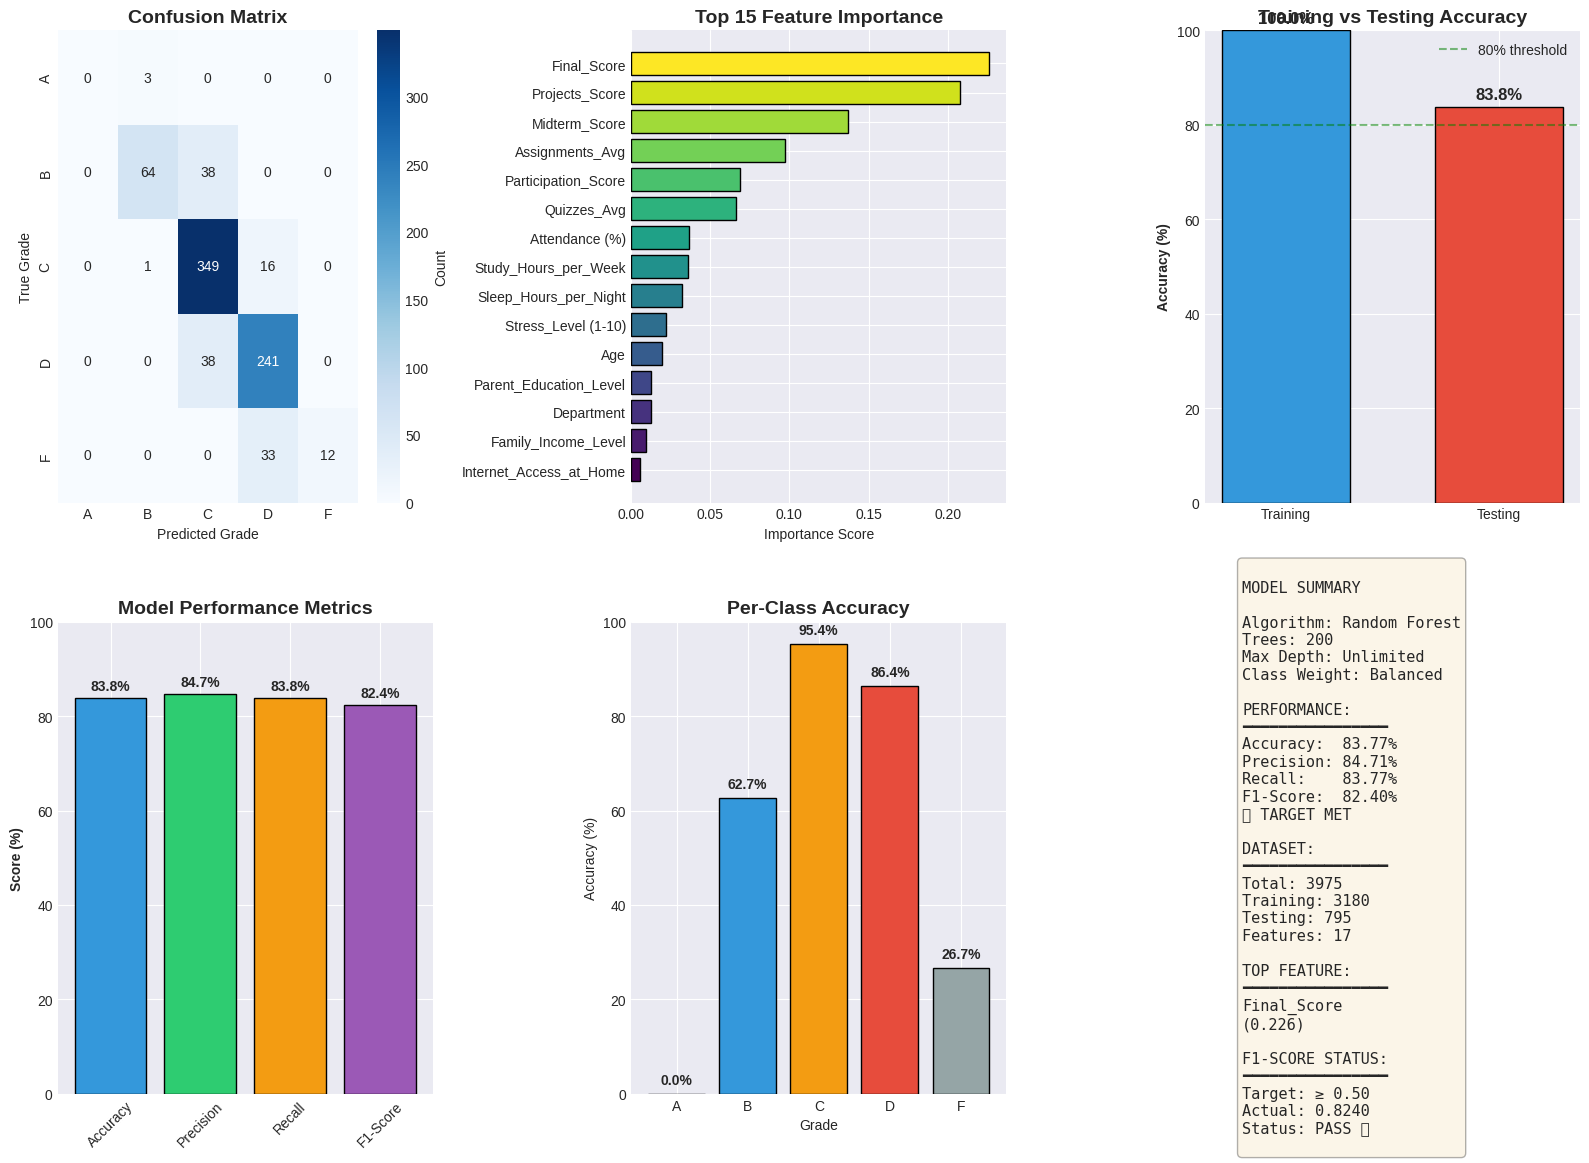

✅ Visualisasi evaluasi tersimpan sebagai 'model_evaluation_results.png'


In [ ]:
print("\n📊 Generating evaluation visualizations...")

fig = plt.figure(figsize=(16, 12))

# 1. Confusion Matrix
ax1 = plt.subplot(2, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Grade')
plt.ylabel('True Grade')

# 2. Feature Importance (Top 15)
ax2 = plt.subplot(2, 3, 2)
top_n_features = min(15, len(feature_importance))
top_features = feature_importance.head(top_n_features).sort_values('importance')
colors_importance = plt.cm.viridis(np.linspace(0, 1, len(top_features)))
ax2.barh(top_features['feature'], top_features['importance'], color=colors_importance, edgecolor='black')
plt.xlabel('Importance Score')
plt.title(f'Top {top_n_features} Feature Importance', fontsize=14, fontweight='bold')

# 3. Training vs Testing Accuracy
ax3 = plt.subplot(2, 3, 3)
categories = ['Training', 'Testing']
accuracies = [train_accuracy * 100, test_accuracy * 100]
bars = ax3.bar(categories, accuracies, color=['#3498db', '#e74c3c'],
               edgecolor='black', width=0.6)
ax3.set_ylim([0, 100])
ax3.set_ylabel('Accuracy (%)', fontweight='bold')
ax3.set_title('Training vs Testing Accuracy', fontsize=14, fontweight='bold')
ax3.axhline(y=80, color='green', linestyle='--', alpha=0.5, label='80% threshold')
for i, (bar, v) in enumerate(zip(bars, accuracies)):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{v:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax3.legend()

# 4. All Metrics Comparison
ax4 = plt.subplot(2, 3, 4)
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [test_accuracy * 100, precision * 100, recall * 100, f1 * 100]
colors_metrics = ['#3498db', '#2ecc71', '#f39c12', '#9b59b6']
bars = ax4.bar(metrics_names, metrics_values, color=colors_metrics, edgecolor='black')
ax4.set_ylim([0, 100])
ax4.set_ylabel('Score (%)', fontweight='bold')
ax4.set_title('Model Performance Metrics', fontsize=14, fontweight='bold')
ax4.tick_params(axis='x', rotation=45)
for bar, v in zip(bars, metrics_values):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

# 5. Per-Class Accuracy
ax5 = plt.subplot(2, 3, 5)
per_class_accuracy = []
for i, grade in enumerate(le_target.classes_):
    mask = y_test == i
    if mask.sum() > 0:
        class_acc = accuracy_score(y_test[mask], y_test_pred[mask]) * 100
        per_class_accuracy.append(class_acc)
    else:
        per_class_accuracy.append(0)

ax5.bar(le_target.classes_, per_class_accuracy,
        color=colors_grade[:len(le_target.classes_)], edgecolor='black')
ax5.set_xlabel('Grade')
ax5.set_ylabel('Accuracy (%)')
ax5.set_title('Per-Class Accuracy', fontsize=14, fontweight='bold')
ax5.set_ylim([0, 100])
for i, v in enumerate(per_class_accuracy):
    ax5.text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

# 6. Model Summary Box
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
summary_text = f"""
MODEL SUMMARY

Algorithm: Random Forest
Trees: 200
Max Depth: Unlimited
Class Weight: Balanced

PERFORMANCE:
━━━━━━━━━━━━━━━━
Accuracy:  {test_accuracy*100:.2f}%
Precision: {precision*100:.2f}%
Recall:    {recall*100:.2f}%
F1-Score:  {f1*100:.2f}%
{'✅ TARGET MET' if f1 >= 0.50 else '❌ BELOW TARGET'}

DATASET:
━━━━━━━━━━━━━━━━
Total: {len(df_clean)}
Training: {len(X_train)}
Testing: {len(X_test)}
Features: {len(X.columns)}

TOP FEATURE:
━━━━━━━━━━━━━━━━
{feature_importance.iloc[0]['feature'][:20]}
({feature_importance.iloc[0]['importance']:.3f})

F1-SCORE STATUS:
━━━━━━━━━━━━━━━━
Target: ≥ 0.50
Actual: {f1:.4f}
{'Status: PASS ✅' if f1 >= 0.50 else 'Status: FAIL ❌'}
"""
ax6.text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
         verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig('model_evaluation_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualisasi evaluasi tersimpan sebagai 'model_evaluation_results.png'")


# **KESIMPULAN**

In [ ]:
print("\n" + "="*60)
print("✅ KESIMPULAN")
print("="*60)

print(f"\n📊 RINGKASAN PROYEK:")
print(f"   • Dataset: {len(df_clean)} students, {len(X.columns)} features")
print(f"   • Target: Grade Classification ({', '.join(le_target.classes_)})")
print(f"   • Model: Random Forest Classifier")
print(f"   • Akurasi Testing: {test_accuracy*100:.2f}%")
print(f"   • Feature Terpenting: {feature_importance.iloc[0]['feature']}")

print(f"\n💡 INSIGHTS:")
print(f"   1. Model berhasil memprediksi grade dengan akurasi {test_accuracy*100:.1f}%")
print(f"   2. {feature_importance.iloc[0]['feature']} adalah faktor paling berpengaruh")
print(f"   3. Gap Train-Test: {abs(train_accuracy-test_accuracy)*100:.1f}% {'(Good - No Overfitting)' if abs(train_accuracy-test_accuracy) < 0.1 else '(Watch for Overfitting)'}")
print(f"   4. Model siap digunakan untuk prediksi grade siswa baru")

print("\n" + "="*60)

# Save Model
import pickle
with open('student_grading_model.pkl', 'wb') as f:
    pickle.dump({
        'model': model,
        'scaler': scaler,
        'label_encoder': le_target,
        'feature_names': list(X.columns),
        'categorical_encoders': le_dict
    }, f)

print("💾 Model & preprocessing objects tersimpan sebagai 'student_grading_model.pkl'")
print("\n🎉 ANALISIS SELESAI! Semua file output sudah tersimpan.")
print("="*60)


✅ KESIMPULAN

📊 RINGKASAN PROYEK:
   • Dataset: 3975 students, 17 features
   • Target: Grade Classification (A, B, C, D, F)
   • Model: Random Forest Classifier
   • Akurasi Testing: 83.77%
   • Feature Terpenting: Final_Score

💡 INSIGHTS:
   1. Model berhasil memprediksi grade dengan akurasi 83.8%
   2. Final_Score adalah faktor paling berpengaruh
   3. Gap Train-Test: 16.2% (Watch for Overfitting)
   4. Model siap digunakan untuk prediksi grade siswa baru

💾 Model & preprocessing objects tersimpan sebagai 'student_grading_model.pkl'

🎉 ANALISIS SELESAI! Semua file output sudah tersimpan.
